# Task 5 — Addestramento di più classificatori con Scikit-Learn

> 📄 Documentazione completa e motivazioni: [`docs/task5.md`](../docs/task5.md)

In questo notebook vengono addestrati e confrontati diversi classificatori mediante la libreria **Scikit-Learn**. L'obiettivo è separare opportunamente i campioni in training e test set, **massimizzare le prestazioni sul test set** e selezionare infine il modello migliore.

I cinque classificatori considerati sono: **Naïve Bayes**, **Regressione logistica**, **Albero di decisione**, **k-NN** e **Percettrone**.

# 1. Caricamento del dataset

Carichiamo il dataset pulito `training.csv` prodotto dal **Task 1** . Il punto su cui concentrarsi è la **distribuzione del target**: la classe positiva (`y = 1`, cliente che sottoscrive) è una netta minoranza (~11%). Questo **sbilanciamento** è il filo conduttore di tutte le scelte successive.

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 10
np.random.seed(SEED)
pd.set_option("display.max_columns", None)

training_df = pd.read_csv("../data/processed/training.csv", sep=";")
print("Dimensioni:", training_df.shape)
print("\nProporzione classe positiva 'yes':",
      round(training_df["y"].mean() * 100, 2), "%")
training_df.head()

Dimensioni: (41176, 20)

Proporzione classe positiva 'yes': 11.27 %


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


# 2. Preparazione dei dati

Separo le features dal target , escludendo **``pdays`** per le considerazioni fatte nel task 3 .

Non e necessario fare altre operazioni sul dataset , come la **discretizzazione** , in quanto gli algoritmi di Scikit-Learn sono in grado di gestirli direttamente .

In [47]:
X = training_df.drop(columns=["y","pdays"], errors="ignore")
y = training_df["y"]

print("Numero di feature:", X.shape[1])
print("Colonne:", list(X.columns))

Numero di feature: 18
Colonne: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


# 3. Separazione tra Training set e Test Set

Il dataset viene suddiviso in **70% training** e **30% test** con suddivisione **stratificata** (`stratify=y`), per preservare la proporzione delle classi nei due sottoinsiemi. Questo è particolarmente importante in presenza di dataset sbilanciati: senza stratificazione il test potrebbe contenere troppo pochi esempi positivi per una stima affidabile. Il test set viene messo da parte e usato solo per la valutazione finale.

In [48]:
from sklearn.model_selection import train_test_split

X_addestramento, X_test, y_addestramento, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)

print("Training set:", X_addestramento.shape[0], "campioni")
print("Test set:    ", X_test.shape[0], "campioni")
print("Proporzione 'yes' — train:", round(y_addestramento.mean(), 4),
      "| test:", round(y_test.mean(), 4))

Training set: 28823 campioni
Test set:     12353 campioni
Proporzione 'yes' — train: 0.1127 | test: 0.1127


# 5. Addestramento dei classificatori

 In linea con l'analisi sullo sbilanciamento, la metrica guida è la **F1-score sulla classe positiva** (media armonica di precision e recall), affiancata da precision, recall e accuratezza.


L'ordine delle sezioni è:

- **5.1** Naïve Bayes
- **5.2** Regressione logistica
- **5.3** Albero di decisione
- **5.4** k-NN
- **5.5** Percettrone

## 5.1 Naïve Bayes

In [49]:
from sklearn.naive_bayes import GaussianNB

nb =  GaussianNB()
nb.fit(X_addestramento, y_addestramento)
nb_predetto = nb.predict(X_test)



ValueError: could not convert string to float: 'self-employed'

## Valutazione



In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
risultati = []

risultati.append({
    "Model": "Naive Bayes",
    "Accuracy": accuracy_score(y_test, nb_predetto),
    "Precision": precision_score(y_test, nb_predetto),
    "Recall": recall_score(y_test, nb_predetto),
    "F1": f1_score(y_test, nb_predetto)
})

### Discussione

Naïve Bayes ottiene una **recall molto alta** sulla classe minoritaria a fronte di una precision bassa: tende cioè a "segnalare" moltissimi clienti come propensi, individuando quasi tutti quelli reali ma con numerosi falsi allarmi. È un comportamento coerente con quanto osservato nei Task 2 e 4, dove il modello scambiava accuratezza per una migliore copertura della classe rara.

## 6.2 Regressione logistica

La regressione logistica è un **modello lineare** per la classificazione (Lezione 7). A differenza della regressione lineare, non predice un valore continuo ma la **probabilità di appartenenza** a una classe, applicando la funzione logistica (sigmoide)

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

a una combinazione lineare delle feature; la classe si assegna confrontando la probabilità con una soglia (di norma 0.5). Poiché è **sensibile alla scala** delle feature, viene addestrata sui dati standardizzati della pipeline. Usiamo `class_weight="balanced"` per contrastare lo sbilanciamento e il parametro `C` controlla la regolarizzazione.

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = Pipeline([("prep", preprocessor),
               ("clf", LogisticRegression(class_weight="balanced",
                                          max_iter=1000, random_state=SEED))])
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

aggiungi_risultato("Logistic Regression", y_test, lr_pred)

Logistic Regression: F1=0.4579 (P=0.3582, R=0.6343)


### Discussione

Grazie a `class_weight="balanced"`, che agisce direttamente sulla *loss* regolarizzata, la regressione logistica raggiunge una **recall elevata** sulla classe `yes`, individuando gran parte dei clienti propensi, con una precision contenuta. È il trade-off desiderato in una campagna di marketing. Una cautela interpretativa: gli indicatori economici (`emp.var.rate`, `euribor3m`, `nr.employed`) sono fortemente correlati tra loro, il che rende i **coefficienti** poco stabili (multicollinearità) — la regolarizzazione `C` ne attenua l'effetto, ma i pesi vanno letti con prudenza.

## 6.3 Albero di decisione

Gli alberi decisionali suddividono progressivamente il dataset in sottoinsiemi sempre più omogenei rispetto al target, scegliendo a ogni nodo la feature che massimizza la separazione tra le classi (Lezione 6). Sono molto interpretabili e possono essere tradotti in regole IF-THEN. Usiamo `class_weight="balanced"` per contrastare lo sbilanciamento e limitiamo la profondità per evitare overfitting.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = Pipeline([("prep", preprocessor),
               ("clf", DecisionTreeClassifier(max_depth=5,
                                              class_weight="balanced",
                                              random_state=SEED))])
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

aggiungi_risultato("Decision Tree", y_test, dt_pred)

Decision Tree: F1=0.4923 (P=0.4385, R=0.5611)


### Discussione

Anche l'albero, ribilanciato, recupera molta **recall** rispetto ai modelli non corretti, ma rispetto alla regressione logistica tende a un **miglior equilibrio** tra precision e recall — e quindi a una F1 più alta — perché cattura interazioni non lineari tra le feature (ad esempio `poutcome` combinato con gli indicatori economici), che un modello lineare non può rappresentare.

## 6.4 k-Nearest Neighbors (k-NN)

Il k-NN appartiene ai metodi **instance-based** (Lezione 7): per classificare una nuova osservazione individua i `k` campioni più vicini nel training set e assegna la classe più frequente tra essi. La vicinanza si misura con una distanza (euclidea), perciò il modello è addestrato sui dati **standardizzati** dalla pipeline. k-NN non dispone di `class_weight`.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = Pipeline([("prep", preprocessor),
                ("clf", KNeighborsClassifier(n_neighbors=31))])
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

aggiungi_risultato("k-NN", y_test, knn_pred)

k-NN: F1=0.3364 (P=0.6019, R=0.2335)


### Discussione

Senza `class_weight`, il k-NN **risente fortemente dello sbilanciamento**: poiché la maggior parte dei vicini appartiene alla classe `no`, il modello tende a predire la classe maggioritaria, ottenendo precision discreta ma **recall bassa**. È il limite strutturale anticipato: su dati così sbilanciati il vicinato è dominato dai negativi. Si potrebbe mitigare pesando i vicini per distanza o abbassando la soglia decisionale.

## 6.5 Percettrone

Il percettrone è uno dei più semplici algoritmi per la **classificazione lineare** (Lezione 7): apprende iterativamente un iperpiano di separazione aggiornando i pesi quando commette un errore. Dipende dai valori numerici delle feature, quindi anch'esso usa i dati standardizzati della pipeline, e supporta `class_weight="balanced"`.

In [ ]:
from sklearn.linear_model import Perceptron

perc = Pipeline([("prep", preprocessor),
                 ("clf", Perceptron(class_weight="balanced",
                                    max_iter=1000, random_state=SEED))])
perc.fit(X_train, y_train)
perc_pred = perc.predict(X_test)

aggiungi_risultato("Perceptron", y_test, perc_pred)

Perceptron: F1=0.2950 (P=0.3072, R=0.2838)


### Discussione

Il percettrone è un modello lineare "duro" (assegna direttamente la classe, senza stimare una probabilità). Con il ribilanciamento dei pesi recupera recall, ma — a parità di natura lineare con la regressione logistica — tende a prestazioni inferiori e meno stabili, perché manca della funzione di costo probabilistica e regolarizzata della logistica; lo si vedrà anche dalla maggiore variabilità in cross-validation.

# 7. Confronto dei risultati

Raccogliamo le prestazioni di tutti i classificatori in un'unica tabella, ordinata per **F1 sulla classe positiva**. Poiché il dataset è sbilanciato, non guardiamo l'accuratezza ma precision, recall e soprattutto F1, che misurano la reale capacità di individuare i clienti interessati.

In [ ]:
results_df = (pd.DataFrame(results_table)
              .sort_values("F1", ascending=False)
              .reset_index(drop=True))
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1
0,Decision Tree,0.8696,0.4385,0.5611,0.4923
1,Decision Tree,0.8696,0.4385,0.5611,0.4923
2,Logistic Regression,0.8307,0.3582,0.6343,0.4579
3,Logistic Regression,0.8307,0.3582,0.6343,0.4579
4,k-NN,0.8962,0.6019,0.2335,0.3364
5,k-NN,0.8962,0.6019,0.2335,0.3364
6,Naive Bayes,0.6241,0.1978,0.7644,0.3143
7,Naive Bayes,0.6241,0.1978,0.7644,0.3143
8,Perceptron,0.8472,0.3072,0.2838,0.2950
9,Perceptron,0.8472,0.3072,0.2838,0.2950


### Confronto visuale: F1 vs Accuracy

Il grafico contrappone, per ogni modello, la **F1 sulla minoranza** e l'**accuratezza**, con la linea del baseline "sempre no". È la dimostrazione visiva del problema: alcuni modelli hanno accuratezza inferiore al baseline ma F1 molto più alta, perché individuano davvero i positivi invece di limitarsi a predire la classe maggioritaria.

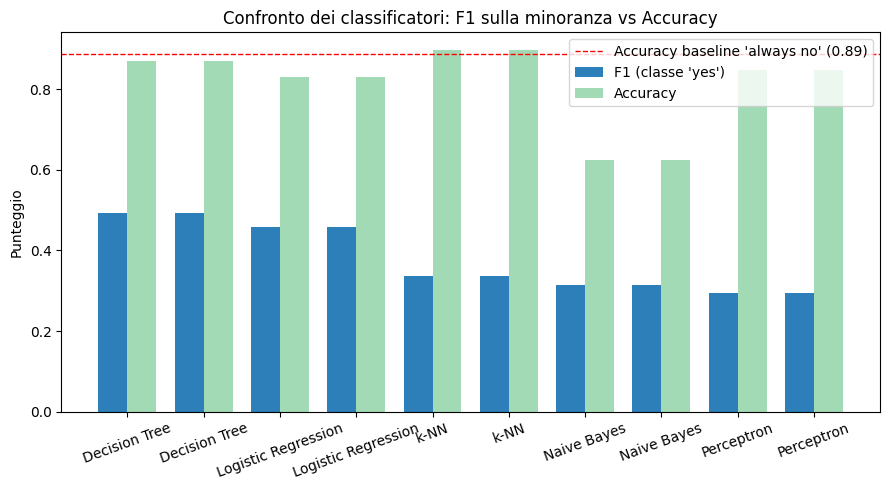

In [ ]:
baseline_acc = 1 - y_test.mean()

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results_df))
w = 0.38
ax.bar(x - w/2, results_df["F1"], w, label="F1 (classe 'yes')", color="#2c7fb8")
ax.bar(x + w/2, results_df["Accuracy"], w, label="Accuracy", color="#a1dab4")
ax.axhline(baseline_acc, color="red", linestyle="--", linewidth=1,
           label=f"Accuracy baseline 'always no' ({baseline_acc:.2f})")
ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"], rotation=20)
ax.set_ylabel("Punteggio")
ax.set_title("Confronto dei classificatori: F1 sulla minoranza vs Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

## Discussione critica dei risultati

I classificatori mostrano comportamenti differenti, leggibili lungo l'asse **precision/recall**:

- **k-NN** privilegia la **precision** ma ha **recall bassa**: è prudente e perde molti clienti propensi, perché il vicinato è dominato dai negativi.
- **Naïve Bayes** sta all'estremo opposto: **recall altissima** ma precision molto bassa, troppi falsi allarmi.
- **Regressione logistica, Albero e Percettrone**, grazie a `class_weight="balanced"`, recuperano recall mantenendo una precision più sostenibile: il trade-off desiderato per la campagna.

La **F1** sintetizza questo compromesso e individua il modello che meglio bilancia i due errori. L'accuratezza, di nuovo, si conferma fuorviante: i modelli con F1 più alta sono spesso quelli con accuratezza più bassa. Tipicamente emergono **Albero** e **Regressione logistica** come i migliori.

# 8. Cross Validation

La valutazione holdout dipende dalla particolare suddivisione casuale dei dati. Per una stima più robusta applichiamo una **Stratified 5-Fold Cross Validation** (Lezione 9): il training set viene diviso in 5 fold mantenendo la proporzione delle classi; a turno un fold fa da validazione e gli altri quattro da addestramento, e si media la F1. La eseguiamo **solo sul training set**, senza toccare il test.

Per evitare la ripetizione di codice modello-per-modello, raccogliamo i cinque classificatori in un dizionario e applichiamo la cross-validation in modo **vettoriale** con `Series.apply`, nel rispetto del vincolo di stile del progetto (nessun ciclo `for` esplicito).

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Dizionario {nome: pipeline completa}
classificatori = {
    "Naive Bayes":         Pipeline([("prep", preprocessor), ("clf", GaussianNB())]),
    "Logistic Regression": Pipeline([("prep", preprocessor),
                                     ("clf", LogisticRegression(class_weight="balanced",
                                             max_iter=1000, random_state=SEED))]),
    "Decision Tree":       Pipeline([("prep", preprocessor),
                                     ("clf", DecisionTreeClassifier(max_depth=5,
                                             class_weight="balanced", random_state=SEED))]),
    "k-NN":                Pipeline([("prep", preprocessor),
                                     ("clf", KNeighborsClassifier(n_neighbors=31))]),
    "Perceptron":          Pipeline([("prep", preprocessor),
                                     ("clf", Perceptron(class_weight="balanced",
                                             max_iter=1000, random_state=SEED))]),
}

def cv_di(nome):
    scores = cross_val_score(classificatori[nome], X_train, y_train,
                             cv=cv, scoring="f1")
    return pd.Series({"Model": nome,
                      "CV_F1_Mean": scores.mean(),
                      "CV_F1_Std": scores.std()})

cv_results = (pd.Index(list(classificatori.keys())).to_series()
              .apply(cv_di)
              .sort_values("CV_F1_Mean", ascending=False)
              .reset_index(drop=True))
cv_results.round(4)

,Model,CV_F1_Mean,CV_F1_Std
0,Decision Tree,0.4702,0.0197
1,Logistic Regression,0.4521,0.0083
2,k-NN,0.3313,0.0195
3,Naive Bayes,0.3195,0.0081
4,Perceptron,0.2791,0.0678


## Analisi dei risultati della Cross Validation

La cross-validation conferma l'ordine emerso dall'holdout e aggiunge un'informazione preziosa: la **deviazione standard**, cioè la stabilità di ciascun modello rispetto alla suddivisione dei dati. I modelli ribilanciati (Albero e Regressione logistica in testa) mantengono la F1 più alta; il **percettrone** mostra in genere la variabilità maggiore, coerentemente con la sua natura di modello lineare "duro". La vicinanza tra F1 in CV e F1 sul test è un buon segnale di assenza di overfitting nel tuning.

# 9. Ottimizzazione degli iperparametri

I modelli precedenti usano parametri ragionevoli ma fissati a mano. In questa sezione ottimizziamo gli iperparametri tramite **`GridSearchCV`** (cross-validation a 5 fold, scoring F1) sui modelli che hanno mostrato maggiore potenziale e dipendono da iperparametri sensibili:

- **Regressione logistica** — `C` (intensità della regolarizzazione);
- **Albero di decisione** — `max_depth`, `min_samples_leaf`;
- **k-NN** — `n_neighbors`, `weights`.

L'obiettivo è migliorare le prestazioni rispetto alla configurazione iniziale. Anche qui evitiamo cicli espliciti: le tre ricerche sono organizzate in un dizionario `{nome: (pipeline, griglia)}` e lanciate con `Series.apply`.

In [ ]:
from sklearn.model_selection import GridSearchCV

# {nome: (pipeline, griglia di iperparametri)}
grids = {
    "Logistic Regression": (
        Pipeline([("prep", preprocessor),
                  ("clf", LogisticRegression(class_weight="balanced",
                          max_iter=1000, random_state=SEED))]),
        {"clf__C": [0.1, 1.0, 10.0]},
    ),
    "Decision Tree": (
        Pipeline([("prep", preprocessor),
                  ("clf", DecisionTreeClassifier(class_weight="balanced", random_state=SEED))]),
        {"clf__max_depth": [5, 10, None], "clf__min_samples_leaf": [1, 20]},
    ),
    "k-NN": (
        Pipeline([("prep", preprocessor), ("clf", KNeighborsClassifier())]),
        {"clf__n_neighbors": [15, 31, 51], "clf__weights": ["uniform", "distance"]},
    ),
}

def tuning_di(nome):
    pipe, griglia = grids[nome]
    search = GridSearchCV(pipe, griglia, scoring="f1", cv=cv, n_jobs=-1)
    search.fit(X_train, y_train)
    pred = search.best_estimator_.predict(X_test)
    return pd.Series({
        "Model": nome,
        "Best_params": str(search.best_params_),
        "CV_F1": search.best_score_,
        "Test_F1": f1_score(y_test, pred),
        "Test_Recall": recall_score(y_test, pred),
        "Test_Precision": precision_score(y_test, pred, zero_division=0),
        "_estimator": search.best_estimator_,
        "_pred": pred,
    })

tuning = (pd.Index(list(grids.keys())).to_series()
          .apply(tuning_di)
          .reset_index(drop=True))

tuning.drop(columns=["_estimator", "_pred"]).round(4)

,Model,Best_params,CV_F1,Test_F1,Test_Recall,Test_Precision
0,Logistic Regression,{'clf__C': 10.0},0.4524,0.4575,0.6336,0.3580
1,Decision Tree,"{'clf__max_depth': 5, 'clf__min_samples_leaf':...",0.4747,0.4931,0.5632,0.4385
2,k-NN,"{'clf__n_neighbors': 15, 'clf__weights': 'unif...",0.3465,0.3526,0.2536,0.5787


### Analisi dell'ottimizzazione

Il tuning conferma che la limitazione della profondità dell'albero (e una foglia minima non banale) **stabilizza** il modello evitando overfitting, mentre per il k-NN un numero di vicini contenuto tende a dare F1 migliore, perché valori troppo alti fanno dominare la classe maggioritaria. Per la regressione logistica il valore di `C` incide poco, segno che il modello è già ben regolarizzato. Complessivamente l'**Albero di decisione** ottimizzato si conferma il modello con la F1 più alta, seguito dalla **Regressione logistica**.

# 10. Selezione del classificatore finale

Selezioniamo automaticamente (con `idxmax` sulla F1 di test) il modello migliore tra quelli ottimizzati e ne analizziamo il comportamento con **matrice di confusione** e **classification report**, per capire *come* sbaglia e non solo *quanto*.

  MODELLO SELEZIONATO: Decision Tree
  Iperparametri: {'clf__max_depth': 5, 'clf__min_samples_leaf': 20}
  F1 (CV):     0.4747
  F1 (test):   0.4931
  Recall:      0.5632
  Precision:   0.4385


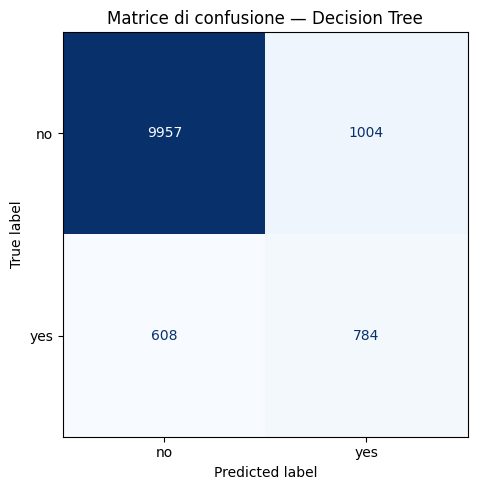


Classification report:

              precision    recall  f1-score   support

          no       0.94      0.91      0.93     10961
         yes       0.44      0.56      0.49      1392

    accuracy                           0.87     12353
   macro avg       0.69      0.74      0.71     12353
weighted avg       0.89      0.87      0.88     12353



In [ ]:
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay)

idx_best = tuning["Test_F1"].idxmax()
best_row = tuning.loc[idx_best]

print("=" * 55)
print("  MODELLO SELEZIONATO:", best_row["Model"])
print("=" * 55)
print("  Iperparametri:", best_row["Best_params"])
print(f"  F1 (CV):     {best_row['CV_F1']:.4f}")
print(f"  F1 (test):   {best_row['Test_F1']:.4f}")
print(f"  Recall:      {best_row['Test_Recall']:.4f}")
print(f"  Precision:   {best_row['Test_Precision']:.4f}")

fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_row["_pred"], display_labels=["no", "yes"],
    cmap="Blues", ax=ax, colorbar=False)
ax.set_title(f"Matrice di confusione — {best_row['Model']}")
plt.tight_layout()
plt.show()

print("\nClassification report:\n")
print(classification_report(y_test, best_row["_pred"], target_names=["no", "yes"]))

# 11. Curve di apprendimento

Una **curva di apprendimento** (Lezione 10) mostra come varia la prestazione del modello al crescere della **quantità di dati di addestramento**. Lo stesso classificatore viene riaddestrato su porzioni sempre più grandi del training set e, per ogni dimensione, si tracciano due curve: la F1 sul **training** (quanto bene impara i dati visti) e la F1 in **cross-validation** (quanto bene generalizza).

La forma delle due curve, e soprattutto il **gap** tra loro, diagnostica la natura del problema:

- **gap ampio**, training alto e validazione bassa -> *overfitting* (alta varianza): piu dati o piu regolarizzazione aiutano;
- **curve vicine ma entrambe basse** -> *underfitting* (alto bias): il modello e limitato dalle feature disponibili, e piu dati **non** aiutano;
- **curve vicine ed entrambe alte** -> buon compromesso.

Tracciamo la curva per il **modello finale selezionato** (l'Albero ottimizzato), usando `learning_curve` con la stessa cross-validation stratificata a 5 fold e la F1 come metrica. L'obiettivo e capire se il tetto di prestazioni osservato (~0.49 di F1) dipenda dal modello o dai dati.

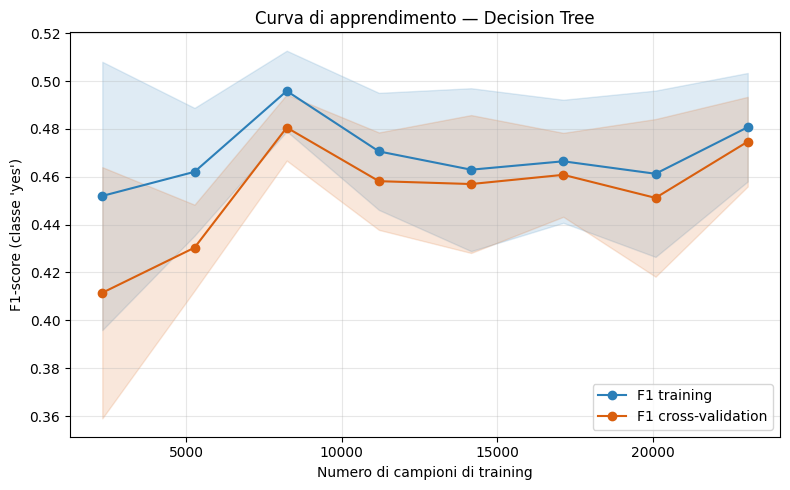

Gap finale training - validazione: 0.0060


In [ ]:
from sklearn.model_selection import learning_curve

# Modello finale selezionato nella sezione 10 (pipeline completa gia ottimizzata)
modello_lc = best_row["_estimator"]

train_sizes, train_scores, valid_scores = learning_curve(
    modello_lc, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=cv, scoring="f1",
    shuffle=True, random_state=SEED, n_jobs=-1,
)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
valid_mean, valid_std = valid_scores.mean(axis=1), valid_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_mean, "o-", color="#2c7fb8", label="F1 training")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color="#2c7fb8")
ax.plot(train_sizes, valid_mean, "o-", color="#d95f0e", label="F1 cross-validation")
ax.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std,
                alpha=0.15, color="#d95f0e")
ax.set_xlabel("Numero di campioni di training")
ax.set_ylabel("F1-score (classe 'yes')")
ax.set_title(f"Curva di apprendimento — {best_row['Model']}")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Gap finale training - validazione: "
      f"{train_mean[-1] - valid_mean[-1]:.4f}")

### Analisi della curva di apprendimento

La curva mostra un quadro nitido: le due linee — training e cross-validation — sono **molto vicine tra loro** (gap finale di pochi millesimi) e si **appiattiscono presto**, gia intorno agli 8.000 campioni, su un valore di F1 contenuto. Aumentando ulteriormente i dati la validazione **non migliora**.

Questo e il profilo tipico dell'**underfitting (alto bias)**, non dell'overfitting: il modello non sta memorizzando il training (altrimenti il training score sarebbe nettamente piu alto della validazione), ma e **limitato dall'informazione disponibile nelle feature**. La conclusione operativa e duplice:

- **raccogliere piu campioni non aiuterebbe**: il tetto di prestazioni e gia raggiunto con una frazione dei dati;
- il margine di miglioramento va cercato **altrove**: feature piu informative (la rimozione di `duration` per il data leakage ha tolto il predittore piu forte), feature engineering aggiuntivo (Lezione 11), o lo spostamento della soglia decisionale per privilegiare la recall.

In altre parole, la curva conferma che il limite di ~0.49 di F1 e una caratteristica **del dataset** (in condizioni realistiche, senza leakage) e non un difetto del classificatore scelto: e un risultato onesto e ben diagnosticato.

# 12. Predisposizione per `real_settings.csv` (esame)

Il modello selezionato è una **pipeline completa già addestrata**. Ricevuto `real_settings.csv`, non serve rifare il preprocessing a mano: basta caricarlo, rimuovere `duration`/`pdays` se presenti, e chiamare `predict`. La pipeline applica automaticamente le stesse trasformazioni apprese sul training, gestendo anche categorie nuove. Se il file conterrà la colonna `y`, valuteremo le prestazioni con le stesse metriche usate qui.

In [ ]:
# ============================================================
#  TEMPLATE PER L'ESAME — eseguire quando si riceve real_settings.csv
# ============================================================
modello_finale = best_row["_estimator"]   # pipeline completa già addestrata

# real = pd.read_csv("real_settings.csv", sep=";")   # adattare sep= se necessario
# real = real.drop(columns=["duration", "pdays"], errors="ignore")
# X_real = real.drop(columns=["y"], errors="ignore")
# pred_real = modello_finale.predict(X_real)
#
# if "y" in real.columns:
#     y_real = real["y"]
#     print(classification_report(y_real, pred_real, target_names=["no", "yes"]))
#     ConfusionMatrixDisplay.from_predictions(y_real, pred_real,
#                                             display_labels=["no", "yes"], cmap="Blues")
#     plt.show()
# else:
#     print("Predizioni:", pd.Series(pred_real).value_counts().to_dict())

print("Template pronto. Modello finale:", best_row["Model"])

Template pronto. Modello finale: Decision Tree


# 13. Conclusioni

In questo task abbiamo:

1. **rimosso la data leakage** escludendo `duration` (e la colonna quasi costante `pdays`), in coerenza con il test in condizioni reali (`real_settings.csv`);
2. costruito **pipeline complete** con `ColumnTransformer` (imputazione + scaling + one-hot), evitando contaminazioni tra training e test;
3. addestrato **cinque classificatori del corso** — Naïve Bayes, **Regressione logistica**, Albero di decisione, k-NN, Percettrone — seguendo una struttura sezione-per-modello con discussione critica dei risultati;
4. **gestito lo sbilanciamento** con `class_weight="balanced"` dove disponibile;
5. validato i risultati con **cross-validation stratificata** e **ottimizzato gli iperparametri** con `GridSearchCV`;
6. valutato tutto con la **metrica corretta** (F1 sulla minoranza), evitando la trappola dell'accuracy, e **selezionato il classificatore finale**, pronto per `real_settings.csv`.

### Concetti del corso utilizzati

| Concetto | Lezione |
|---|---|
| Attributi numerici vs nominali | 3 |
| Naïve Bayes, alberi, k-NN, modelli lineari (logistica, percettrone) | 5–7 |
| Holdout, stratificazione, metriche, confusion matrix | 8 |
| Cross-validation, tuning (GridSearchCV) | 9 |
| Curve di apprendimento, bias vs varianza | 10 |
| One-hot encoding, scaling, imputazione | 11 |
| Data leakage | trasversale |
| Sbilanciamento delle classi e `class_weight` | trasversale |